# Notebook 03 — Modelo 2: CNN-LSTM con capa de atención

**TFM · Máster en Inteligencia Artificial · Manuel Montilla Luna**

**Predicción de Vida Útil Restante (RUL) sobre NASA C-MAPSS**


Esta arquitectura combina tres componentes que atacan aspectos distintos
del problema:

- Convoluciones unidimensionales que extraen patrones locales de degradación a lo largo de
  la ventana temporal, sin necesidad de definir características a mano.
- Una capa recurrente que modela la evolución de esos patrones en el tiempo.
- Un mecanismo de atención que pondera de forma adaptativa la contribución de cada ciclo de
  la ventana a la predicción final.

La hipótesis a contrastar es que no todos los ciclos de la ventana son igualmente informativos,
y que un modelo capaz de aprender esa ponderación superará a la LSTM del notebook 02, que los
trata uniformemente.

El mecanismo de atención aporta además una ventaja de interpretabilidad: sus pesos son
directamente inspeccionables y permiten visualizar en qué instantes se apoya el modelo.

## 1. Configuración del entorno

In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

# Ajusta esta ruta si subes el proyecto a otra carpeta de tu Drive
PROJECT_DIR = Path("/content/drive/MyDrive/ColabNotebooks/tfm")
DATA_DIR    = PROJECT_DIR / "data" / "CMAPSSData"
FIG_DIR     = PROJECT_DIR / "reports" / "figures"
MODELS_DIR  = PROJECT_DIR / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Proyecto : {PROJECT_DIR}")
print(f"Datos    : {DATA_DIR}   (existe: {DATA_DIR.exists()})")

Mounted at /content/drive
Proyecto : /content/drive/MyDrive/ColabNotebooks/tfm
Datos    : /content/drive/MyDrive/ColabNotebooks/tfm/data/CMAPSSData   (existe: True)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
import keras
from keras import layers

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 23
np.random.seed(RANDOM_STATE)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

gpus = tf.config.list_physical_devices("GPU")
print(f"GPU        : {gpus if gpus else 'NO DISPONIBLE - el entrenamiento sera lento'}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Hiperparámetros del experimento

Los parámetros de datos son idénticos a los del notebook 02, condición necesaria para que la
comparación entre arquitecturas sea válida: cualquier diferencia observada debe ser atribuible
al modelo y no al tratamiento de los datos.

In [ ]:
# --- Parámetros de datos (idénticos al notebook 02) ---
SUBSET        = "FD001"
WINDOW        = 30
STRIDE        = 1
RUL_CAP       = 125
VAL_FRAC      = 0.20

# --- Parámetros de entrenamiento ---
EPOCHS        = 100
BATCH_SIZE    = 256
LEARNING_RATE = 1e-3

# --- Parámetros de la arquitectura ---
CONV_FILTERS  = 32     # filtros de cada capa convolucional
KERNEL_SIZE   = 3      # tamaño del núcleo de convolución
LSTM_UNITS    = 32     # unidades de la capa recurrente
ATTN_UNITS    = 64     # dimensión interna del mecanismo de atención
DENSE_UNITS   = 64
DROPOUT       = 0.45

## 3. Esquema de datos y funciones de carga

In [ ]:
# --- Esquema de columnas de C-MAPSS ---------------------------------------
# Los ficheros no traen cabecera. Las 26 columnas son, en orden:
#   unit, cycle, setting_1..3, sensor_1..21

INDEX_COLS   = ["unit", "cycle"]
SETTING_COLS = ["setting_1", "setting_2", "setting_3"]
SENSOR_COLS  = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SUBSETS = ("FD001", "FD002", "FD003", "FD004")

N_CONDITIONS  = {"FD001": 1, "FD002": 6, "FD003": 1, "FD004": 6}
N_FAULT_MODES = {"FD001": 1, "FD002": 1, "FD003": 2, "FD004": 2}


@dataclass
class CMAPSSSubset:
    """Contenedor de un subset completo de C-MAPSS."""

    name: str
    train: pd.DataFrame
    test: pd.DataFrame
    rul_test: pd.Series

    @property
    def n_conditions(self):
        return N_CONDITIONS[self.name]

    @property
    def n_fault_modes(self):
        return N_FAULT_MODES[self.name]

    def summary(self):
        return pd.Series({
            "subset": self.name,
            "condiciones_operativas": self.n_conditions,
            "modos_de_fallo": self.n_fault_modes,
            "motores_train": self.train["unit"].nunique(),
            "motores_test": self.test["unit"].nunique(),
            "filas_train": len(self.train),
            "filas_test": len(self.test),
        })

In [ ]:
def _read_cmapss_file(path):
    """
    Lee un fichero train_FD00X.txt o test_FD00X.txt.

    Los ficheros originales terminan cada linea con dos espacios. Con
    `sep=" "` pandas generaria dos columnas fantasma llenas de NaN; usando la
    expresion regular `\s+` como separador el problema desaparece.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {path}.")

    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    if df.shape[1] != len(ALL_COLS):
        raise ValueError(
            f"{path.name}: se esperaban {len(ALL_COLS)} columnas y se han leido "
            f"{df.shape[1]}.")

    df.columns = ALL_COLS
    return df.astype({"unit": "int32", "cycle": "int32"})


def _read_rul_file(path):
    """Lee RUL_FD00X.txt: una linea por motor de test con su RUL real."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {path}.")

    rul = pd.read_csv(path, sep=r"\s+", header=None, engine="python").iloc[:, 0]
    rul.name = "RUL"
    rul.index = range(1, len(rul) + 1)
    return rul.astype("int32")


def load_subset(name, data_dir=None):
    """Carga un subset completo: train + test + RUL de test."""
    name = name.upper()
    if name not in SUBSETS:
        raise ValueError(f"Subset desconocido: {name}. Opciones: {SUBSETS}")

    data_dir = Path(data_dir if data_dir is not None else DATA_DIR)
    return CMAPSSSubset(
        name=name,
        train=_read_cmapss_file(data_dir / f"train_{name}.txt"),
        test=_read_cmapss_file(data_dir / f"test_{name}.txt"),
        rul_test=_read_rul_file(data_dir / f"RUL_{name}.txt"),
    )

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1274/1065177080.py:7: SyntaxWarning: invalid escape sequence '\s'
  expresion regular `\s+` como separador el problema desaparece.


## 4. Preprocesado

Pipeline idéntico al del notebook 02. Se reproduce aquí para que el cuaderno sea autocontenido.

In [ ]:
def add_rul_train(df, rul_cap=125):
    """
    RUL del conjunto de entrenamiento: ultimo_ciclo - ciclo_actual, con tope.

    El tope produce el perfil de degradacion lineal a trozos. Su justificacion
    es que un motor nuevo no se degrada de forma apreciable: exigir al modelo
    que distinga entre 300 y 290 ciclos restantes no tiene reflejo fisico.
    """
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df


def add_rul_test(df, rul_test, rul_cap=125):
    """RUL del conjunto de test, sumando el remanente de RUL_FD00X.txt."""
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    remaining = df["unit"].map(rul_test)
    df["RUL"] = (max_cycle - df["cycle"]) + remaining
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df


def fit_regime_clusterer(train, n_conditions):
    """K-Means sobre las variables de ajuste. None si solo hay un regimen."""
    if n_conditions <= 1:
        return None
    km = KMeans(n_clusters=n_conditions, random_state=RANDOM_STATE, n_init=10)
    km.fit(train[SETTING_COLS].values)
    return km


def assign_regime(df, clusterer):
    """Indice de regimen de cada fila (0 si solo hay un regimen)."""
    if clusterer is None:
        return np.zeros(len(df), dtype=int)
    return clusterer.predict(df[SETTING_COLS].values)


def fit_regime_scalers(train, regimes, feature_cols):
    """Un MinMaxScaler independiente por regimen, ajustado solo con train."""
    scalers = {}
    for r in np.unique(regimes):
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train.loc[regimes == r, feature_cols].values)
        scalers[int(r)] = scaler
    return scalers


def apply_regime_scalers(df, regimes, scalers, feature_cols):
    """Aplica a cada fila el escalador de su regimen."""
    df = df.copy()
    values = df[feature_cols].values.astype(np.float64)
    out = np.empty_like(values)
    for r, scaler in scalers.items():
        mask = regimes == r
        if mask.any():
            out[mask] = scaler.transform(values[mask])
    df[feature_cols] = out
    return df


def find_uninformative_sensors(train, regimes=None, threshold=1e-6):
    """
    Sensores sin varianza informativa.

    El calculo debe hacerse DENTRO de cada regimen: en FD002/FD004 varios
    sensores son constantes dentro de cada regimen de vuelo pero toman valores
    distintos entre regimenes, de modo que medidos globalmente pareceria que
    aportan informacion cuando solo codifican el regimen.
    """
    if regimes is None:
        stds = train[SENSOR_COLS].std()
    else:
        per_regime = [train.loc[regimes == r, SENSOR_COLS].std()
                      for r in np.unique(regimes)]
        stds = pd.concat(per_regime, axis=1).max(axis=1)
    return sorted(stds[stds < threshold].index.tolist(),
                  key=lambda c: int(c.split("_")[1]))


def make_windows_train(df, feature_cols, window=30, stride=1):
    """Ventanas deslizantes de train. El target es el RUL del ultimo ciclo."""
    X_list, y_list, unit_list = [], [], []
    for unit, group in df.groupby("unit", sort=True):
        group = group.sort_values("cycle")
        feats = group[feature_cols].values.astype(np.float32)
        target = group["RUL"].values.astype(np.float32)
        if len(group) < window:
            continue
        for start in range(0, len(group) - window + 1, stride):
            end = start + window
            X_list.append(feats[start:end])
            y_list.append(target[end - 1])
            unit_list.append(unit)
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            np.asarray(unit_list, dtype=np.int32))


def make_windows_test(df, feature_cols, window=30):
    """
    Una ventana por motor de test: la ultima disponible.

    Motores mas cortos que la ventana: padding por repeticion del primer ciclo,
    preferible a descartarlos para no sesgar la evaluacion hacia casos faciles.
    """
    X_list, unit_list = [], []
    for unit, group in df.groupby("unit", sort=True):
        group = group.sort_values("cycle")
        feats = group[feature_cols].values.astype(np.float32)
        if len(feats) < window:
            pad = np.repeat(feats[:1], window - len(feats), axis=0)
            feats = np.vstack([pad, feats])
        X_list.append(feats[-window:])
        unit_list.append(unit)
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(unit_list, dtype=np.int32))


def split_by_unit(X, y, units, val_frac=0.2):
    """
    Validacion reservando motores COMPLETOS.

    Un split por filas dejaria ventanas solapadas casi identicas a ambos lados
    y produciria metricas de validacion optimistas.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    unique_units = np.unique(units)
    rng.shuffle(unique_units)
    n_val = max(1, int(round(len(unique_units) * val_frac)))
    val_units = set(unique_units[:n_val].tolist())
    val_mask = np.isin(units, list(val_units))
    return X[~val_mask], y[~val_mask], X[val_mask], y[val_mask]


@dataclass
class PreparedData:
    """Resultado del pipeline completo, listo para alimentar a Keras."""

    subset: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    test_units: np.ndarray
    feature_cols: list
    dropped_sensors: list
    window: int = 30
    rul_cap: int = 125

    @property
    def n_features(self):
        return len(self.feature_cols)

    def report(self):
        return (f"[{self.subset}] ventana={self.window}  features={self.n_features}  "
                f"cap RUL={self.rul_cap}\n"
                f"  sensores descartados : {len(self.dropped_sensors)}\n"
                f"  X_train : {self.X_train.shape}\n"
                f"  X_val   : {self.X_val.shape}\n"
                f"  X_test  : {self.X_test.shape}")


def prepare(subset, window=30, stride=1, rul_cap=125, val_frac=0.2,
            use_settings=False):
    """Pipeline completo de preprocesado sobre un subset."""
    train = add_rul_train(subset.train, rul_cap=rul_cap)
    test  = add_rul_test(subset.test, subset.rul_test, rul_cap=rul_cap)

    # Regimenes ANTES de la seleccion de variables
    clusterer     = fit_regime_clusterer(train, subset.n_conditions)
    train_regimes = assign_regime(train, clusterer)
    test_regimes  = assign_regime(test, clusterer)

    dropped      = find_uninformative_sensors(train, regimes=train_regimes)
    sensor_cols  = [c for c in SENSOR_COLS if c not in dropped]
    feature_cols = sensor_cols + (SETTING_COLS if use_settings else [])

    # Escaladores ajustados SOLO con train
    scalers = fit_regime_scalers(train, train_regimes, feature_cols)
    train   = apply_regime_scalers(train, train_regimes, scalers, feature_cols)
    test    = apply_regime_scalers(test, test_regimes, scalers, feature_cols)

    X, y, units = make_windows_train(train, feature_cols, window=window, stride=stride)
    X_train, y_train, X_val, y_val = split_by_unit(X, y, units, val_frac=val_frac)

    X_test, test_units = make_windows_test(test, feature_cols, window=window)
    y_test = subset.rul_test.reindex(test_units).values.astype(np.float32)
    if rul_cap is not None:
        y_test = np.clip(y_test, None, rul_cap)

    return PreparedData(
        subset=subset.name, X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        test_units=test_units, feature_cols=feature_cols,
        dropped_sensors=dropped, window=window, rul_cap=rul_cap)

## 5. Métricas de evaluación

In [ ]:
def rmse(y_true, y_pred):
    """Raiz del error cuadratico medio."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def mae(y_true, y_pred):
    """Error absoluto medio."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.mean(np.abs(y_pred - y_true)))


def nasa_score(y_true, y_pred):
    """
    Funcion de puntuacion asimetrica de NASA (PHM 2008). Menor es mejor.

    Penaliza mas la sobreestimacion que la subestimacion del RUL: predecir que
    a un motor le quedan mas ciclos de los reales implica que la intervencion
    de mantenimiento llega tarde, con riesgo de fallo en servicio.
    """
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(s))


def evaluate(y_true, y_pred, name="modelo"):
    """Bloque completo de metricas de un modelo."""
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    d = y_pred - y_true
    return pd.Series({
        "modelo": name,
        "RMSE": round(rmse(y_true, y_pred), 3),
        "MAE": round(mae(y_true, y_pred), 3),
        "NASA_Score": round(nasa_score(y_true, y_pred), 1),
        "sesgo_medio": round(float(np.mean(d)), 3),
        "pct_retrasadas": round(float(np.mean(d > 0) * 100), 1),
    })


def comparison_table(results):
    """Tabla comparativa ordenada por RMSE."""
    return pd.DataFrame(results).set_index("modelo").sort_values("RMSE")


def default_callbacks(checkpoint_path=None, patience=15, reduce_lr_patience=7):
    """
    Callbacks usados en todos los entrenamientos.

    EarlyStopping con restore_best_weights garantiza que el modelo evaluado sea
    el de mejor validacion, no el de la ultima epoca.
    """
    cbs = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=reduce_lr_patience,
            min_lr=1e-5, verbose=1),
    ]
    if checkpoint_path:
        cbs.append(keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0))
    return cbs

## 6. Ejecución del pipeline

In [ ]:
subset = load_subset(SUBSET, DATA_DIR)
data = prepare(subset, window=WINDOW, stride=STRIDE, rul_cap=RUL_CAP,
               val_frac=VAL_FRAC, use_settings=subset.n_conditions > 1)
print(data.report())

[FD001] ventana=30  features=15  cap RUL=125
  sensores descartados : 6
  X_train : (14381, 30, 15)
  X_val   : (3350, 30, 15)
  X_test  : (100, 30, 15)


## 7. Arquitectura del modelo

```
Input (WINDOW, n_features)
   ↓
Conv1D(64, k=3, padding='same', relu) + BatchNorm     ← patrones locales
Conv1D(64, k=3, padding='same', relu) + BatchNorm
   ↓
LSTM(64, return_sequences=True)                        ← evolución temporal
   ↓
TemporalAttention  →  contexto (64,)  +  pesos (30, 1) ← ponderación adaptativa
   ↓
Dense(64, relu) + Dropout(0.3)
Dense(1)                                               ← RUL estimado
```

### El mecanismo de atención

Se implementa una atención aditiva de tipo Bahdanau, adaptada al caso de una única
secuencia. Para cada instante *t* de la ventana, la capa calcula una puntuación escalar a
partir del estado oculto correspondiente:

$$e_t = v^{\top} \tanh(W h_t)$$

Esas puntuaciones se normalizan mediante softmax sobre la dimensión temporal, produciendo un
vector de pesos que suma uno:

$$\alpha_t = \frac{\exp(e_t)}{\sum_{k=1}^{T}\exp(e_k)}$$

Y el vector de contexto sobre el que se emite la predicción es la media ponderada de los
estados ocultos:

$$c = \sum_{t=1}^{T} \alpha_t \, h_t$$

La diferencia con la LSTM del notebook 02 es precisa: allí la predicción se emitía a partir del
último estado oculto exclusivamente, mientras que aquí se emite a partir de una combinación de
todos ellos, con pesos que el modelo aprende.

Nota de implementación. La capa devuelve tanto el contexto como los pesos, lo que permite
construir un segundo modelo que comparte las mismas capas y expone los pesos para su
inspección. El decorador de registro es necesario para que el modelo pueda guardarse y
recuperarse en formato `.keras` con una capa personalizada.

In [ ]:
@keras.saving.register_keras_serializable(package="tfm")
class TemporalAttention(layers.Layer):
    """
    Atencion aditiva (Bahdanau) sobre la dimension temporal.

    Recibe una secuencia de estados ocultos (batch, T, H) y devuelve:
      - context : (batch, H)     media ponderada de los estados
      - weights : (batch, T, 1)  pesos de atencion, suman 1 sobre T

    Los pesos son el elemento interpretable: indican en que ciclos de la
    ventana se apoya el modelo para emitir su prediccion.
    """

    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = layers.Dense(units, activation="tanh", name="attn_W")
        self.v = layers.Dense(1, use_bias=False, name="attn_v")

    def call(self, inputs):
        score   = self.v(self.W(inputs))                 # (batch, T, 1)
        weights = keras.ops.softmax(score, axis=1)       # normaliza sobre T
        context = keras.ops.sum(weights * inputs, axis=1)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

In [ ]:
def build_cnn_lstm_attention(window, n_features,
                            conv_filters=CONV_FILTERS, kernel_size=KERNEL_SIZE,
                            lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS,
                            dense_units=DENSE_UNITS, dropout=DROPOUT,
                            learning_rate=LEARNING_RATE, seed=RANDOM_STATE,
                            name="cnn_lstm_atencion"):
    """
    Arquitectura hibrida convolucional-recurrente con atencion temporal.

    Devuelve dos modelos que COMPARTEN las mismas capas y por tanto los mismos
    pesos: el modelo de regresion que se entrena, y un modelo auxiliar que
    expone los pesos de atencion para su inspeccion.
    """
    keras.utils.set_random_seed(seed)

    inputs = keras.Input(shape=(window, n_features), name="ventana_sensores")

    # Bloque convolucional: extraccion de patrones locales.
    # padding="same" preserva la longitud de la secuencia, de modo que los
    # pesos de atencion siguen siendo interpretables ciclo a ciclo.
    x = layers.Conv1D(conv_filters, kernel_size, padding="same",
                      activation="relu", name="conv_1")(inputs)
    x = layers.LayerNormalization(name="bn_1")(x)
    x = layers.Conv1D(conv_filters, kernel_size, padding="same",
                      activation="relu", name="conv_2")(x)
    x = layers.LayerNormalization(name="bn_2")(x)

    # Bloque recurrente: devuelve la secuencia completa para que la atencion
    # pueda operar sobre todos los instantes.
    x = layers.LSTM(lstm_units, return_sequences=True, name="lstm")(x)

    # Atencion temporal
    context, attn_weights = TemporalAttention(attn_units, name="atencion")(x)

    # Cabeza de regresion
    h = layers.Dense(dense_units, activation="relu", name="dense_oculta")(context)
    h = layers.Dropout(dropout, name="dropout")(h)
    outputs = layers.Dense(1, name="rul")(h)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])

    # Modelo auxiliar de inspeccion. No se entrena: comparte pesos con el
    # anterior, de modo que se actualiza automaticamente al entrenar aquel.
    attention_model = keras.Model(inputs, attn_weights, name="inspector_atencion")

    return model, attention_model

In [ ]:
model, attention_model = build_cnn_lstm_attention(
    window=data.window, n_features=data.n_features)
model.summary()

Model: "cnn_lstm_atencion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ventana_sensores (InputLayer)   │ (None, 30, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv1D)                 │ (None, 30, 32)         │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (LayerNormalization)       │ (None, 30, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 30, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (LayerNormalization)       │ (None, 30, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ atencion (TemporalAttention)    │ [(None, 32), (None,    │         2,176 │
│                                 │ 30, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_oculta (Dense)            │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,377 (67.88 KB)

 Trainable params: 17,377 (67.88 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento

In [ ]:
ckpt = MODELS_DIR / f"cnn_lstm_attn_{SUBSET}.keras"

history = model.fit(
    data.X_train, data.y_train / RUL_CAP,                 # ← escalado
    validation_data=(data.X_val, data.y_val / RUL_CAP),   # ← escalado
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=default_callbacks(checkpoint_path=str(ckpt)),
    verbose=1,
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0821 - mae: 0.2254 - rmse: 0.2865 - val_loss: 0.0398 - val_mae: 0.1670 - val_rmse: 0.1994 - learning_rate: 0.0010
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0485 - mae: 0.1721 - rmse: 0.2201 - val_loss: 0.0324 - val_mae: 0.1475 - val_rmse: 0.1801 - learning_rate: 0.0010
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0414 - mae: 0.1563 - rmse: 0.2035 - val_loss: 0.0270 - val_mae: 0.1308 - val_rmse: 0.1644 - learning_rate: 0.0010
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0373 - mae: 0.1491 - rmse: 0.1932 - val_loss: 0.0291 - val_mae: 0.1373 - val_rmse: 0.1705 - learning_rate: 0.0010
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0340 - mae: 0.1405 - rmse: 0.1844 - val_loss: 0.0250 - val_mae: 0.1259 - val_rmse: 0.1580 - learning_rate: 0.0010
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0306 - mae: 0.1331 - rmse: 0.1749 - val_loss: 0.0240 - val

## 9. Curvas de aprendizaje

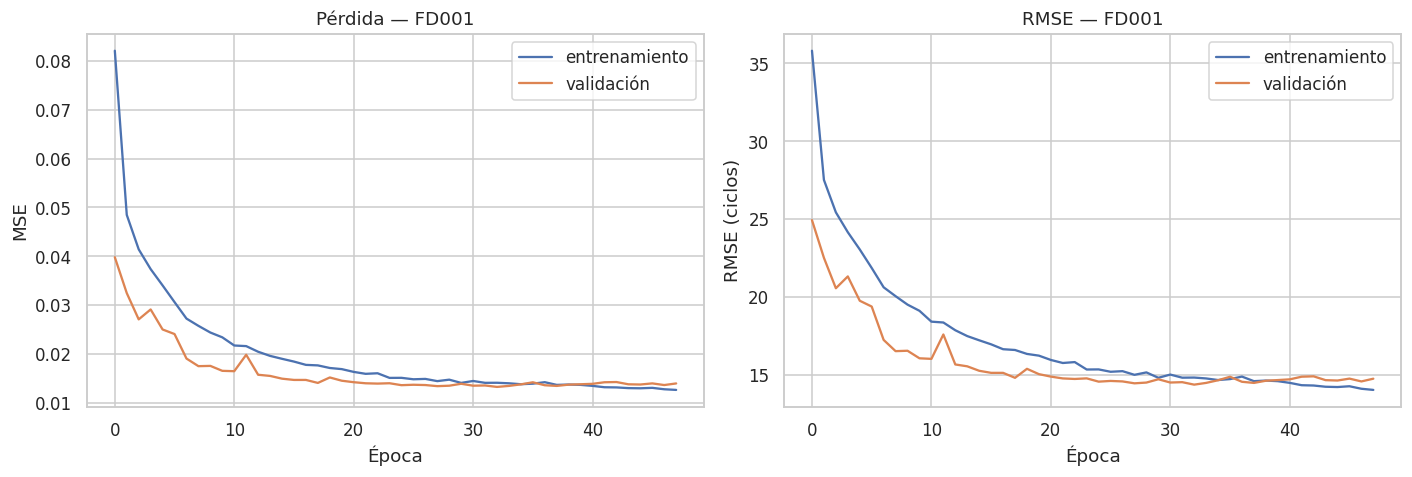

Épocas ejecutadas : 48
Mejor val_RMSE    : 0.115 ciclos


In [ ]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(h["loss"], label="entrenamiento")
axes[0].plot(h["val_loss"], label="validación")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE")
axes[0].set_title(f"Pérdida — {SUBSET}"); axes[0].legend()

axes[1].plot(np.array(h["rmse"]) * RUL_CAP, label="entrenamiento")
axes[1].plot(np.array(h["val_rmse"]) * RUL_CAP, label="validación")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("RMSE (ciclos)")
axes[1].set_title(f"RMSE — {SUBSET}"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / f"curvas_aprendizaje_cnnlstm_{SUBSET}.png", bbox_inches="tight")
plt.show()

print(f"Épocas ejecutadas : {len(h['loss'])}")
print(f"Mejor val_RMSE    : {min(h['val_rmse']):.3f} ciclos")

## 10. Evaluación sobre el conjunto de test

In [ ]:
y_pred = model.predict(data.X_test, verbose=0).ravel() * RUL_CAP   # ← desescalado
y_pred = np.clip(y_pred, 0, RUL_CAP)

resultado = evaluate(data.y_test, y_pred, name=f"CNN-LSTM-Attn_{SUBSET}")
print(resultado.to_string())

modelo            CNN-LSTM-Attn_FD001
RMSE                           14.106
MAE                            10.319
NASA_Score                      374.2
sesgo_medio                     2.108
pct_retrasadas                   61.0


### Interpretación de referencia

Valores publicados en la literatura para FD001, como orden de magnitud:

| Enfoque | RMSE |
|---|---|
| LSTM | ~16 |
| BiLSTM | ~14 |
| CNN profunda | ~12,6 |
| Arquitecturas con atención | ~11,5–12 |

## 11. Diagnóstico visual de las predicciones

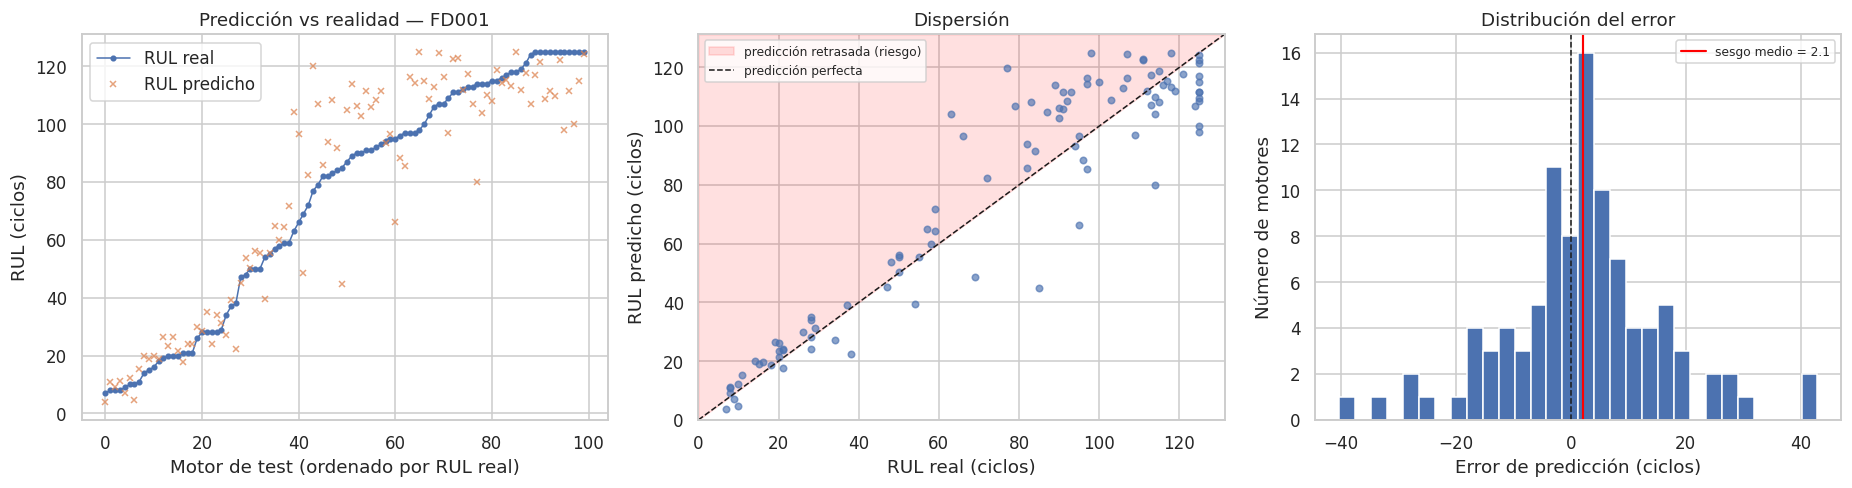

In [ ]:
y_true = data.y_test
err = y_pred - y_true
order = np.argsort(y_true)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

axes[0].plot(y_true[order], "o-", ms=3, lw=1, label="RUL real")
axes[0].plot(y_pred[order], "x", ms=4, alpha=0.75, label="RUL predicho")
axes[0].set_xlabel("Motor de test (ordenado por RUL real)")
axes[0].set_ylabel("RUL (ciclos)")
axes[0].set_title(f"Predicción vs realidad — {SUBSET}"); axes[0].legend()

lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
axes[1].fill_between(lim, lim, lim[1], alpha=0.12, color="red",
                     label="predicción retrasada (riesgo)")
axes[1].scatter(y_true, y_pred, s=18, alpha=0.65)
axes[1].plot(lim, lim, "k--", lw=1, label="predicción perfecta")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("RUL real (ciclos)"); axes[1].set_ylabel("RUL predicho (ciclos)")
axes[1].set_title("Dispersión"); axes[1].legend(fontsize=8)

axes[2].hist(err, bins=30, edgecolor="white")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].axvline(err.mean(), color="red", lw=1.4, label=f"sesgo medio = {err.mean():.1f}")
axes[2].set_xlabel("Error de predicción (ciclos)")
axes[2].set_ylabel("Número de motores")
axes[2].set_title("Distribución del error"); axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / f"predicciones_cnnlstm_{SUBSET}.png", bbox_inches="tight")
plt.show()

## 12. Interpretabilidad: análisis de los pesos de atención

Esta sección es la aportación diferencial del modelo.

Los pesos de atención indican qué ciclos de la ventana pondera más el modelo al emitir su
predicción. Al sumar uno sobre la dimensión temporal, admiten una lectura directa: un peso de
0,10 en el ciclo *t* significa que ese instante aporta el 10 % del vector de contexto.

La pregunta que responde el análisis es si el modelo se apoya preferentemente en los ciclos
finales de la ventana —los más próximos al instante de predicción— o si distribuye su atención
de forma más homogénea. Y, sobre todo, si ese comportamiento cambia según el estado de
degradación del motor.

In [ ]:
# Los pesos se obtienen del modelo auxiliar, que comparte pesos con el entrenado
attn = attention_model.predict(data.X_test, verbose=0)   # (n_motores, WINDOW, 1)
attn = attn.squeeze(-1)                                   # (n_motores, WINDOW)

print(f"Forma de los pesos     : {attn.shape}")
print(f"Suma por ventana       : {attn.sum(axis=1)[:5].round(4)}  (debe ser 1.0)")
print(f"Peso medio por posición : min={attn.mean(axis=0).min():.4f}  "
      f"max={attn.mean(axis=0).max():.4f}  uniforme={1/WINDOW:.4f}")

Forma de los pesos     : (100, 30)
Suma por ventana       : [1. 1. 1. 1. 1.]  (debe ser 1.0)
Peso medio por posición : min=0.0128  max=0.2739  uniforme=0.0333


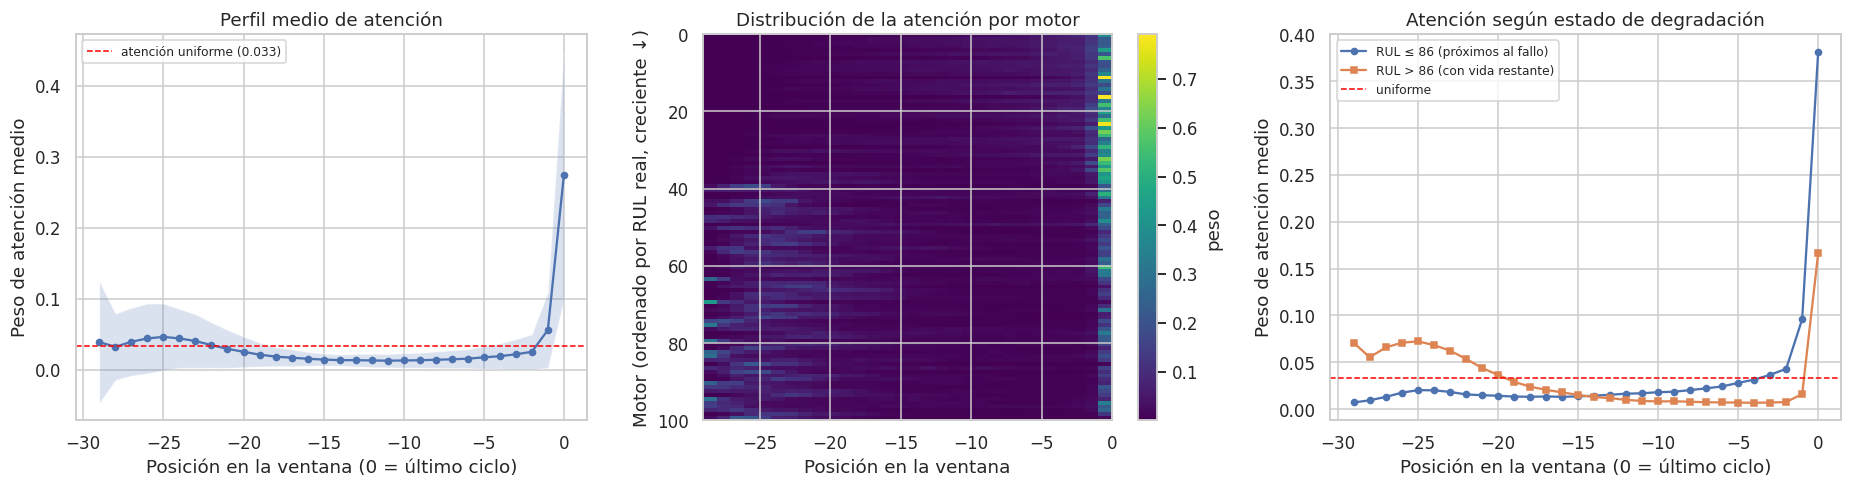

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# Panel 1 — perfil medio de atención a lo largo de la ventana
perfil = attn.mean(axis=0)
desv   = attn.std(axis=0)
ciclos = np.arange(-WINDOW + 1, 1)   # 0 = último ciclo observado

axes[0].plot(ciclos, perfil, "o-", ms=4, lw=1.5)
axes[0].fill_between(ciclos, perfil - desv, perfil + desv, alpha=0.2)
axes[0].axhline(1 / WINDOW, color="red", ls="--", lw=1,
                label=f"atención uniforme ({1/WINDOW:.3f})")
axes[0].set_xlabel("Posición en la ventana (0 = último ciclo)")
axes[0].set_ylabel("Peso de atención medio")
axes[0].set_title("Perfil medio de atención")
axes[0].legend(fontsize=8)

# Panel 2 — mapa de calor, motores ordenados por RUL real
orden = np.argsort(data.y_test)
im = axes[1].imshow(attn[orden], aspect="auto", cmap="viridis",
                    extent=[-WINDOW + 1, 0, len(attn), 0])
axes[1].set_xlabel("Posición en la ventana")
axes[1].set_ylabel("Motor (ordenado por RUL real, creciente ↓)")
axes[1].set_title("Distribución de la atención por motor")
plt.colorbar(im, ax=axes[1], label="peso")

# Panel 3 — comparación entre motores próximos al fallo y motores sanos
umbral = np.median(data.y_test)
criticos = attn[data.y_test <= umbral].mean(axis=0)
sanos    = attn[data.y_test >  umbral].mean(axis=0)

axes[2].plot(ciclos, criticos, "o-", ms=4, label=f"RUL ≤ {umbral:.0f} (próximos al fallo)")
axes[2].plot(ciclos, sanos, "s-", ms=4, label=f"RUL > {umbral:.0f} (con vida restante)")
axes[2].axhline(1 / WINDOW, color="red", ls="--", lw=1, label="uniforme")
axes[2].set_xlabel("Posición en la ventana (0 = último ciclo)")
axes[2].set_ylabel("Peso de atención medio")
axes[2].set_title("Atención según estado de degradación")
axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / f"atencion_cnnlstm_{SUBSET}.png", bbox_inches="tight")
plt.show()

In [ ]:
# Cuantificación: ¿cuánta atención se concentra en el último tercio de la ventana?
tercio = WINDOW // 3
concentracion = attn[:, -tercio:].sum(axis=1)

print(f"Atención acumulada en los últimos {tercio} ciclos de la ventana")
print(f"  media    : {concentracion.mean():.3f}")
print(f"  mediana  : {np.median(concentracion):.3f}")
print(f"  esperado si fuese uniforme : {tercio/WINDOW:.3f}")
print()

# Entropía de la distribución de atención: baja = concentrada, alta = dispersa
eps = 1e-12
entropia = -(attn * np.log(attn + eps)).sum(axis=1)
print(f"Entropía media de la atención : {entropia.mean():.3f}")
print(f"Entropía máxima (uniforme)    : {np.log(WINDOW):.3f}")
print(f"Ratio de concentración        : {1 - entropia.mean()/np.log(WINDOW):.1%}")

Atención acumulada en los últimos 10 ciclos de la ventana
  media    : 0.471
  mediana  : 0.416
  esperado si fuese uniforme : 0.333

Entropía media de la atención : 2.547
Entropía máxima (uniforme)    : 3.401
Ratio de concentración        : 25.1%


## 13. Entrenamiento sobre los cuatro subsets

In [ ]:
TODOS = ["FD001", "FD002", "FD003", "FD004"]
resultados = []

for nombre in TODOS:
    print(f"\n{'='*70}\n  {nombre}\n{'='*70}")
    s = load_subset(nombre, DATA_DIR)
    d = prepare(s, window=WINDOW, stride=STRIDE, rul_cap=RUL_CAP,
                val_frac=VAL_FRAC, use_settings=s.n_conditions > 1)
    print(d.report())

    m, _ = build_cnn_lstm_attention(window=d.window, n_features=d.n_features)
    m.fit(d.X_train, d.y_train / RUL_CAP,
          validation_data=(d.X_val, d.y_val / RUL_CAP),
          epochs=EPOCHS, batch_size=BATCH_SIZE,
          callbacks=default_callbacks(
              checkpoint_path=str(MODELS_DIR / f"cnn_lstm_attn_{nombre}.keras")),
          verbose=0)

    p = np.clip(m.predict(d.X_test, verbose=0).ravel() * RUL_CAP, 0, RUL_CAP)
    r = evaluate(d.y_test, p, name=f"CNN-LSTM-Attn_{nombre}")
    print(r.to_string())
    resultados.append(r)

tabla = comparison_table(resultados)
(PROJECT_DIR / "reports").mkdir(parents=True, exist_ok=True)
tabla.to_csv(PROJECT_DIR / "reports" / "resultados_cnnlstm.csv")
tabla


  FD001
[FD001] ventana=30  features=15  cap RUL=125
  sensores descartados : 6
  X_train : (14381, 30, 15)
  X_val   : (3350, 30, 15)
  X_test  : (100, 30, 15)

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 38.
modelo            CNN-LSTM-Attn_FD001
RMSE                           14.326
MAE                            10.197
NASA_Score                      389.7
sesgo_medio                     1.371
pct_retrasadas                   54.0

  FD002
[FD002] ventana=30  features=20  cap RUL=125
  sensores descartados : 4
  X_train : (36545, 30, 20)
  X_val   : (9674, 30, 20)
  X_test  : (259, 30, 20)

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 26: early stopping
Restoring model weights fr

,RMSE,MAE,NASA_Score,sesgo_medio,pct_retrasadas
modelo,,,,,
CNN-LSTM-Attn_FD003,12.868,9.450,311.7,4.662,67.0
CNN-LSTM-Attn_FD001,14.326,10.197,389.7,1.371,54.0
CNN-LSTM-Attn_FD002,15.145,11.339,1299.8,0.618,46.7
CNN-LSTM-Attn_FD004,17.071,12.402,1684.6,1.252,47.6


### Comparación con el modelo 1

,LSTM,CNN-LSTM-Attn,mejora,mejora_%
FD001,13.923,14.326,-0.403,-2.9
FD002,14.434,15.145,-0.711,-4.9
FD003,13.423,12.868,0.555,4.1
FD004,15.425,17.071,-1.646,-10.7


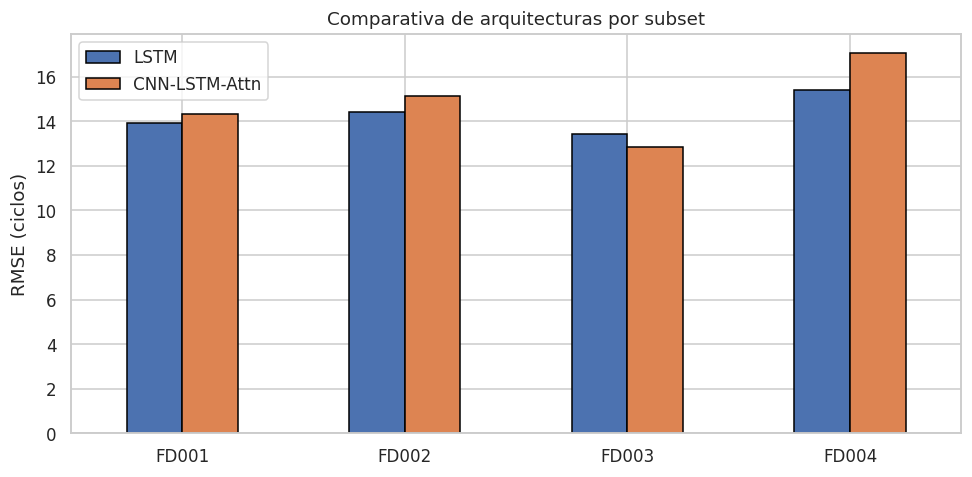

In [ ]:
ruta_lstm = PROJECT_DIR / "reports" / "resultados_lstm.csv"

if ruta_lstm.exists():
    prev = pd.read_csv(ruta_lstm, index_col=0)
    comp = pd.DataFrame({
        "LSTM": prev["RMSE"].values,
        "CNN-LSTM-Attn": tabla["RMSE"].values,
    }, index=[i.split("_")[-1] for i in tabla.index]).sort_index()
    comp["mejora"] = (comp["LSTM"] - comp["CNN-LSTM-Attn"]).round(3)
    comp["mejora_%"] = (100 * comp["mejora"] / comp["LSTM"]).round(1)
    display(comp)

    ax = comp[["LSTM", "CNN-LSTM-Attn"]].plot(kind="bar", figsize=(9, 4.5),
                                              edgecolor="black")
    ax.set_ylabel("RMSE (ciclos)")
    ax.set_title("Comparativa de arquitecturas por subset")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "comparativa_lstm_vs_cnnlstm.png", bbox_inches="tight")
    plt.show()
else:
    print("Ejecuta antes el notebook 02 para generar resultados_lstm.csv")

## 14. Robustez frente a la semilla aleatoria

In [ ]:
SEMILLAS = [23, 7, 2024]
repeticiones = []

for semilla in SEMILLAS:
    m, _ = build_cnn_lstm_attention(window=data.window, n_features=data.n_features,
                                    seed=semilla)
    m.fit(data.X_train, data.y_train / RUL_CAP,
          validation_data=(data.X_val, data.y_val / RUL_CAP),
          epochs=EPOCHS, batch_size=BATCH_SIZE,
          callbacks=default_callbacks(), verbose=0)
    p = np.clip(m.predict(data.X_test, verbose=0).ravel() * RUL_CAP, 0, RUL_CAP)
    r = evaluate(data.y_test, p, name=f"semilla_{semilla}")
    repeticiones.append(r)
    print(f"semilla {semilla:>5} -> RMSE {r['RMSE']:.3f}   NASA {r['NASA_Score']:.1f}")

rep = pd.DataFrame(repeticiones).set_index("modelo")
print(f"\nRMSE       : {rep['RMSE'].mean():.2f} ± {rep['RMSE'].std():.2f}")
print(f"NASA Score : {rep['NASA_Score'].mean():.1f} ± {rep['NASA_Score'].std():.1f}")


Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 33.
semilla    23 -> RMSE 14.176   NASA 366.0

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 58: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 60: early stopping
Restoring model weights from the end of the best epoch: 45.
semilla     7 -> RMSE 13.760   NASA 357.7

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 55: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 63: early stopping
Restoring model weig